# **Intro**

This project explores different time series forecasting approaches, including classical statistical methods, machine learning techniques, deep learning models, and hybrid approaches.

The analysis is based on two datasets representing book sales for The Alchemist and The Very Hungry Caterpillar. The aim is to compare forecasting performance across different time series behaviours and assess model suitability for each case.

The project focuses on building a full forecasting pipeline, including data preparation, stationarity testing, model development, evaluation, and interpretation of results from a business perspective.

# **Problem Statement**

This project analyses sales data for two books from Nielsen’s dataset — The Very Hungry Caterpillar and The Alchemist — to identify trends and seasonal patterns that can be used to produce reliable forecasts.

The objective is to evaluate how forecasting models can support practical business decisions, particularly in procurement, reordering, and inventory management.

# **Libraries**

In [ ]:
!pip install sktime "numpy<2.0" pmdarima tensorflow

In [ ]:
!pip install keras-tuner --upgrade

  Using cached keras_tuner-1.4.8-py3-none-any.whl.metadata (5.6 kB)
  Using cached kt_legacy-1.0.5-py3-none-any.whl.metadata (221 bytes)
Using cached keras_tuner-1.4.8-py3-none-any.whl (129 kB)
Using cached kt_legacy-1.0.5-py3-none-any.whl (9.6 kB)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import pmdarima as pm
import tensorflow as tf
import sktime
import keras_tuner as kt
import math
import random
from sktime.forecasting.arima import AutoARIMA
from datetime import datetime, timedelta
from matplotlib.patches import Rectangle
import matplotlib.animation as animation
from matplotlib import animation
from matplotlib import rc
import matplotlib.ticker as mtick
import statsmodels.graphics.api as smgraphics # gives access to all plotting functions in statsmodels.
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.seasonal import STL
from scipy.stats import boxcox
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from pmdarima.arima import auto_arima
from statsmodels.tsa.stattools import acf
from sklearn.metrics import mean_squared_error
from sktime.forecasting.compose import (TransformedTargetForecaster, make_reduction)
from sktime.forecasting.model_selection import (ExpandingWindowSplitter, ForecastingGridSearchCV)
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams["figure.figsize"] = (10, 5)
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.transformations.series.detrend import Deseasonalizer, Detrender
from xgboost import XGBRegressor
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from sklearn.model_selection import TimeSeriesSplit
import warnings
from os import error
import os
import shutil
from IPython.display import display
# Suppress all warnings.
warnings.filterwarnings("ignore")

print(" All libraries imported successfully!")


 All libraries imported successfully!


In [ ]:
#setting the random seed to ensure reproducibility of results
seed = 42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# **Preprocessing**

In [ ]:
# Mount your drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_dictionary_UK  = pd.read_csv("data/book_sales.csv")

In [ ]:
print(data_dictionary_UK.keys())

dict_keys(['F Adult Fiction', 'S Adult Non-Fiction Specialist', 'T Adult Non-Fiction Trade', "Y Children's, YA & Educational"])


In [ ]:
data_dictionary_ISBN=pd.read_excel("data/book_sales.xlsx")

In [ ]:
print(data_dictionary_ISBN.keys())

dict_keys(['F - Adult Fiction', 'S Adult Non-Fiction Specialist', 'T Adult Non-Fiction Trade', "Y Children's, YA & Educational"])


In [ ]:
# Combine all sheets in data_dictionary_UK  into a single DataFrame with an extra column to identify the sheet
df_UK_weekly = pd.concat(
    [df.assign(Category=sheet_name) for sheet_name, df in data_dictionary_UK.items()],
    ignore_index=True
)


In [ ]:
df_UK_weekly.head()

,ISBN,Title,Author,Interval,End Date,Volume,Value,ASP,RRP,Binding,Imprint,Publisher Group,Product Class,Category
0,9780002261821,One For My Baby,"Parsons, Tony",200513,2005-04-02,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
1,9780002261821,One For My Baby,"Parsons, Tony",200503,2005-01-22,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2,9780002261821,One For My Baby,"Parsons, Tony",200422,2004-05-29,1,11.19,11.19,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
3,9780002261821,One For My Baby,"Parsons, Tony",200415,2004-04-10,2,27.18,13.59,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
4,9780002261821,One For My Baby,"Parsons, Tony",200404,2004-01-24,2,22.48,11.24,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


In [ ]:
# Combine all sheets in data_dictionary_ISBN  into a single DataFrame with an extra column to identify the sheet
df_ISBN = pd.concat(
    [df.assign(Category=sheet_name) for sheet_name, df in data_dictionary_ISBN.items()],
    ignore_index=True
)

In [ ]:
df_ISBN.head()

,ISBN,Title,Author,Imprint,Publisher Group,RRP,Binding,Publication Date,Product Class,Country of Publication,Category
0,9780330375252,Bridget Jones's Diary (Film Tie-in),"Fielding, Helen",Picador,Pan Macmillan Grp,8.99,Paperback,2001-03-23,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction
1,9780140276336,White Teeth,"Smith, Zadie",Penguin Books Ltd,Penguin Grp,9.99,Paperback,2001-01-25,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction
2,9780006512134,Man and Boy,"Parsons, Tony",HarperCollins Publishers,HarperCollins Grp,8.99,Paperback,2000-03-06,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction
3,9780099280255,"Brethren,The","Grisham, John",Arrow Books,Random House Grp,6.99,Paperback,2000-12-27,"F2.1 Crime, Thriller & Adventure",United Kingdom,F - Adult Fiction
4,9780552998727,Marrying The Mistress:an irresistible and grip...,"Trollope, Joanna",Black Swan,Transworld Grp,10.99,Paperback,2001-02-01,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction


Note that the data provided is weekly data.

If no sales happened in a particular week, there will be no data representation for that week. This means that the data is not at fixed intervals.

As a result, resample the data and fill in missing values with 0, such that even weeks with 0 sales is represented.

Convert the ISBNs to a string value.

Convert date to datetime object. (Recall that setting the date as the index has several advantages for time series handling.)

In [ ]:
#replace spaces with underscores across all column names
df_UK_weekly.columns = df_UK_weekly.columns.str.replace(' ', '_')
df_ISBN.columns = df_ISBN.columns.str.replace(' ', '_')

In [ ]:
# Convert ISBN to string
df_UK_weekly['ISBN'] = df_UK_weekly['ISBN'].astype(str)

In [ ]:
df_ISBN['ISBN'] = df_ISBN['ISBN'].astype(str)

In [ ]:
# Ensure End Date is datetime and set as index
df_UK_weekly['End_Date'] = pd.to_datetime(df_UK_weekly['End_Date'])

In [ ]:
# Set 'End_Date' as the index
df_UK_weekly.set_index('End_Date', inplace=True)

In [ ]:
df_UK_weekly.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2005-04-02,9780002261821,One For My Baby,"Parsons, Tony",200513,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2005-01-22,9780002261821,One For My Baby,"Parsons, Tony",200503,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2004-05-29,9780002261821,One For My Baby,"Parsons, Tony",200422,1,11.19,11.19,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2004-04-10,9780002261821,One For My Baby,"Parsons, Tony",200415,2,27.18,13.59,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2004-01-24,9780002261821,One For My Baby,"Parsons, Tony",200404,2,22.48,11.24,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


In [ ]:
df_UK_weekly.shape

(227224, 13)

In [ ]:
# Sort the dataframe chronologically by the End_Date index
df_UK_weekly.sort_index(inplace=True)

In [ ]:
df_UK_weekly.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2001-01-06,9781841461502,KS2 English Study Book - Ages 7-11,CGP Books,200101,700,2370.97,3.3871,6.50,Paperback,Coordination Group Publications Ltd (CGP),Coordination Group Publications,Y5.1 School Textbooks & Study Guides: Literatu...,"Y Children's, YA & Educational"
2001-01-06,9780130125071,Java How to Program,"Deitel, Harvey M. & Deitel, Paul J.",200101,72,2267.40,31.4917,38.09,Hardback,Prentice-Hall,Pearson Education: Prof Grp,S10.2 Computing: Professional & Programming,S Adult Non-Fiction Specialist
2001-01-06,9780563384311,Delia's How To Cook: Book Two,"Smith, Delia",200101,1878,21032.36,11.1993,20.00,Hardback,BBC Books (Random House),Random House Grp,T16.0 Food & Drink: General,T Adult Non-Fiction Trade
2001-01-06,9780340704622,Business Studies,"Marcouse, Ian & Martin, Barry & Surridge, Malc...",200101,90,1698.07,18.8674,NaN,Paperback,Hodder & Stoughton Ltd,Hodder & Stoughton Grp,"S4.0T Business, Accounting & Vocational: Textb...",S Adult Non-Fiction Specialist
2001-01-06,9781841462301,KS3 Science Revision Guide – Higher (includes ...,CGP Books,200101,463,1618.41,3.4955,6.50,Hardback,Coordination Group Publications Ltd (CGP),Coordination Group Publications,"Y5.3 School Textbooks & Study Guides: Maths, S...","Y Children's, YA & Educational"


In [ ]:
df_UK_weekly.tail()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2024-07-20,9780099771517,Memoirs of a Geisha,"Golden, Arthur",202429,43,409.64,9.5265,9.99,Paperback,Vintage,Random House Grp,F1.1 General & Literary Fiction,F Adult Fiction
2024-07-20,9780241003008,"Very Hungry Caterpillar, The","Carle, Eric",202429,2574,11507.46,4.4707,7.99,Hardback,Puffin Books,Penguin Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2024-07-20,9780006647553,Mog’s Bad Thing,"Kerr, Judith",202429,11,86.89,7.8991,7.99,Paperback,HarperCollins Publishers,HarperCollins Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2024-07-20,9780006531203,In the Heart of the Sea,"Philbrick, Nathaniel",202429,3,32.97,10.9900,10.99,Paperback,HarperCollins Publishers,HarperCollins Grp,T5.3 History: Specific Subjects,T Adult Non-Fiction Trade
2024-07-20,9780006550433,"Bonesetter’s Daughter, The","Tan, Amy",202429,1,9.99,9.9900,9.99,Paperback,Flamingo,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


In [ ]:
df_UK_weekly_g = (
    df_UK_weekly
    .groupby('ISBN')
    .resample('W')
    .sum()
    .fillna(0)
)

# Remove duplicate index level before reset_index
df_UK_weekly_g.index = df_UK_weekly_g.index.droplevel(0)  # drop 'ISBN' from index
df_UK_weekly_g = df_UK_weekly_g.reset_index()


In [ ]:
df_UK_weekly_g.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382871 entries, 0 to 382870
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   End_Date         382871 non-null  datetime64[ns]
 1   ISBN             382871 non-null  object        
 2   Title            382871 non-null  object        
 3   Author           382871 non-null  object        
 4   Interval         382871 non-null  int64         
 5   Volume           382871 non-null  int64         
 6   Value            382871 non-null  float64       
 7   ASP              382871 non-null  float64       
 8   RRP              382871 non-null  float64       
 9   Binding          382871 non-null  object        
 10  Imprint          382871 non-null  object        
 11  Publisher_Group  382871 non-null  object        
 12  Product_Class    382871 non-null  object        
 13  Category         382871 non-null  object        
dtypes: datetime64[ns](1)

In [ ]:
df_UK_weekly_g.head()

,End_Date,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
0,2001-01-07,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200101,522,2544.07,4.8737,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
1,2001-01-14,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200102,379,1842.21,4.8607,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
2,2001-01-21,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200103,393,1921.19,4.8885,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
3,2001-01-28,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200104,369,1785.31,4.8382,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
4,2001-02-04,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200105,423,2060.07,4.8701,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"


In [ ]:
df_UK_weekly_g.tail()

,End_Date,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
382866,2008-11-23,0,0,0,0,0,0.00,0.00,0.00,0,0,0,0,0
382867,2008-11-30,0,0,0,0,0,0.00,0.00,0.00,0,0,0,0,0
382868,2008-12-07,9781903840122,"Wicked Book of Txt Tlk, The",0,200849,1,0.40,0.40,1.99,Paperback,Buster Books,Michael O'Mara Grp,Y4.1 Children's General Interest & Leisure,"Y Children's, YA & Educational"
382869,2008-12-14,9781903840122,"Wicked Book of Txt Tlk, The",0,200850,4,1.60,0.40,1.99,Paperback,Buster Books,Michael O'Mara Grp,Y4.1 Children's General Interest & Leisure,"Y Children's, YA & Educational"
382870,2008-12-21,9781903840122,"Wicked Book of Txt Tlk, The",0,200851,2,2.38,1.19,1.99,Paperback,Buster Books,Michael O'Mara Grp,Y4.1 Children's General Interest & Leisure,"Y Children's, YA & Educational"


In [ ]:
# Set End_Date as index
df_UK_weekly_g.set_index('End_Date', inplace=True)

# Sort the dataframe chronologically
df_UK_weekly_g.sort_index(inplace=True)

In [ ]:
df_UK_weekly_g.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2001-01-07,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200101,522,2544.07,4.8737,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
2001-01-07,9780003224764,Psychology for AS-level,"Cardwell, Mike & Clark, Liz & Meldrum, Claire",200101,40,482.56,12.0640,12.99,Paperback,Collins Educational,HarperCollins Grp,S2.2T Psychology: Textbooks & Study Guides,S Adult Non-Fiction Specialist
2001-01-07,9780718144395,"Return of the Naked Chef, The","Oliver, Jamie",200101,5742,83782.37,14.5911,20.00,Hardback,Michael Joseph,Penguin Grp,T16.0 Food & Drink: General,T Adult Non-Fiction Trade
2001-01-07,9780552998727,Marrying the Mistress,"Trollope, Joanna",200101,573,4005.18,6.9898,10.99,Paperback,Black Swan,Transworld Grp,F1.1 General & Literary Fiction,F Adult Fiction
2001-01-07,9780115519772,Highway Code,0,200101,6185,9168.94,1.4824,1.49,Paperback,Stationery Office Books,The Stationery Office Grp,T12.2 Driving & The Highway Code,T Adult Non-Fiction Trade


In [ ]:
df_UK_weekly_g.tail()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2024-07-21,9780744523232,We're Going on a Bear Hunt,"Rosen, Michael",202429,1556,6546.74,4.2074,7.99,Paperback,Walker Books Ltd,Walker Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2024-07-21,9780552145060,Journey,"Steel, Danielle",202429,2,18.38,9.1900,9.99,Paperback,Corgi Books,Transworld Grp,F1.1 General & Literary Fiction,F Adult Fiction
2024-07-21,9780006647553,Mog’s Bad Thing,"Kerr, Judith",202429,11,86.89,7.8991,7.99,Paperback,HarperCollins Publishers,HarperCollins Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2024-07-21,9780440864141,Jacqueline Wilson Double Decker,"Wilson, Jacqueline",202429,5,38.91,7.7820,7.99,Paperback,Yearling (imprint of Random House Children's B...,Random House Childrens Books Grp,Y2.1 Children's Fiction,"Y Children's, YA & Educational"
2024-07-21,9780752844299,Arthur: The Seeing Stone,"Crossley-Holland, Kevin",202429,6,39.49,6.5817,6.99,Paperback,Orion (an Imprint of The Orion Publishing Grou...,Orion Grp,Y2.2 Young Adult Fiction,"Y Children's, YA & Educational"


Filter out the ISBNs (from all four tabs) wherein sales data exists beyond 2024-07-01.

Show all the ISBNs that satisfy this criterion. Capture this in your report.

In [ ]:
# Filter df_UK_weekly for records with sales data beyond 2024-07-01
df_UK_weekly_filtered = df_UK_weekly_g[df_UK_weekly_g.index > '2024-07-01']

In [ ]:
# Get the list of ISBNs that meet the condition
isbn_filtered = df_UK_weekly_filtered['ISBN'].unique()

In [ ]:
len(isbn_filtered )

62

In [ ]:
# Show the filtered ISBNs
print(isbn_filtered)

['9780099244721' 0 '9780140276336' '9780099422587' '9780719559792'
 '9781841461502' '9780006514213' '9780261103252' '9780140275421'
 '9780349113609' '9780722532935' '9780752844299' '9780340766057'
 '9780552998482' '9780552998444' '9780552997348' '9780349112763'
 '9780552145954' '9781841462509' '9780552997034' '9780593048153'
 '9780091867775' '9780099285823' '9780440864554' '9780552998000'
 '9781841150437' '9780552998727' '9780140285215' '9780006647553'
 '9780006514091' '9780099771517' '9780749397548' '9781841460307'
 '9780140259506' '9780140276619' '9780140294231' '9780241003008'
 '9780747268161' '9780340696767' '9780749395698' '9780099428558'
 '9780744523232' '9780006531203' '9781841462400' '9781841462301'
 '9780091816971' '9780140281293' '9780006512134' '9781841460406'
 '9780440864141' '9780140295962' '9780099286578' '9780349114033'
 '9780224060875' '9780340786055' '9780330355667' '9780007101887'
 '9780552145060' '9780752846576' '9780006550433' '9780099286387'
 '9780552145053']


Plot the data of all the ISBNs from the previous step by placing them in a loop.

In [ ]:
# Create a plot grid (e.g., 8x8 grid for 64 slots, leaving some empty space for 61 ISBNs)
num_plots = len(isbn_filtered)
rows = (num_plots // 6) + (1 if num_plots % 6 != 0 else 0)  # Calculate number of rows needed
cols = 6  # 8 plots per row

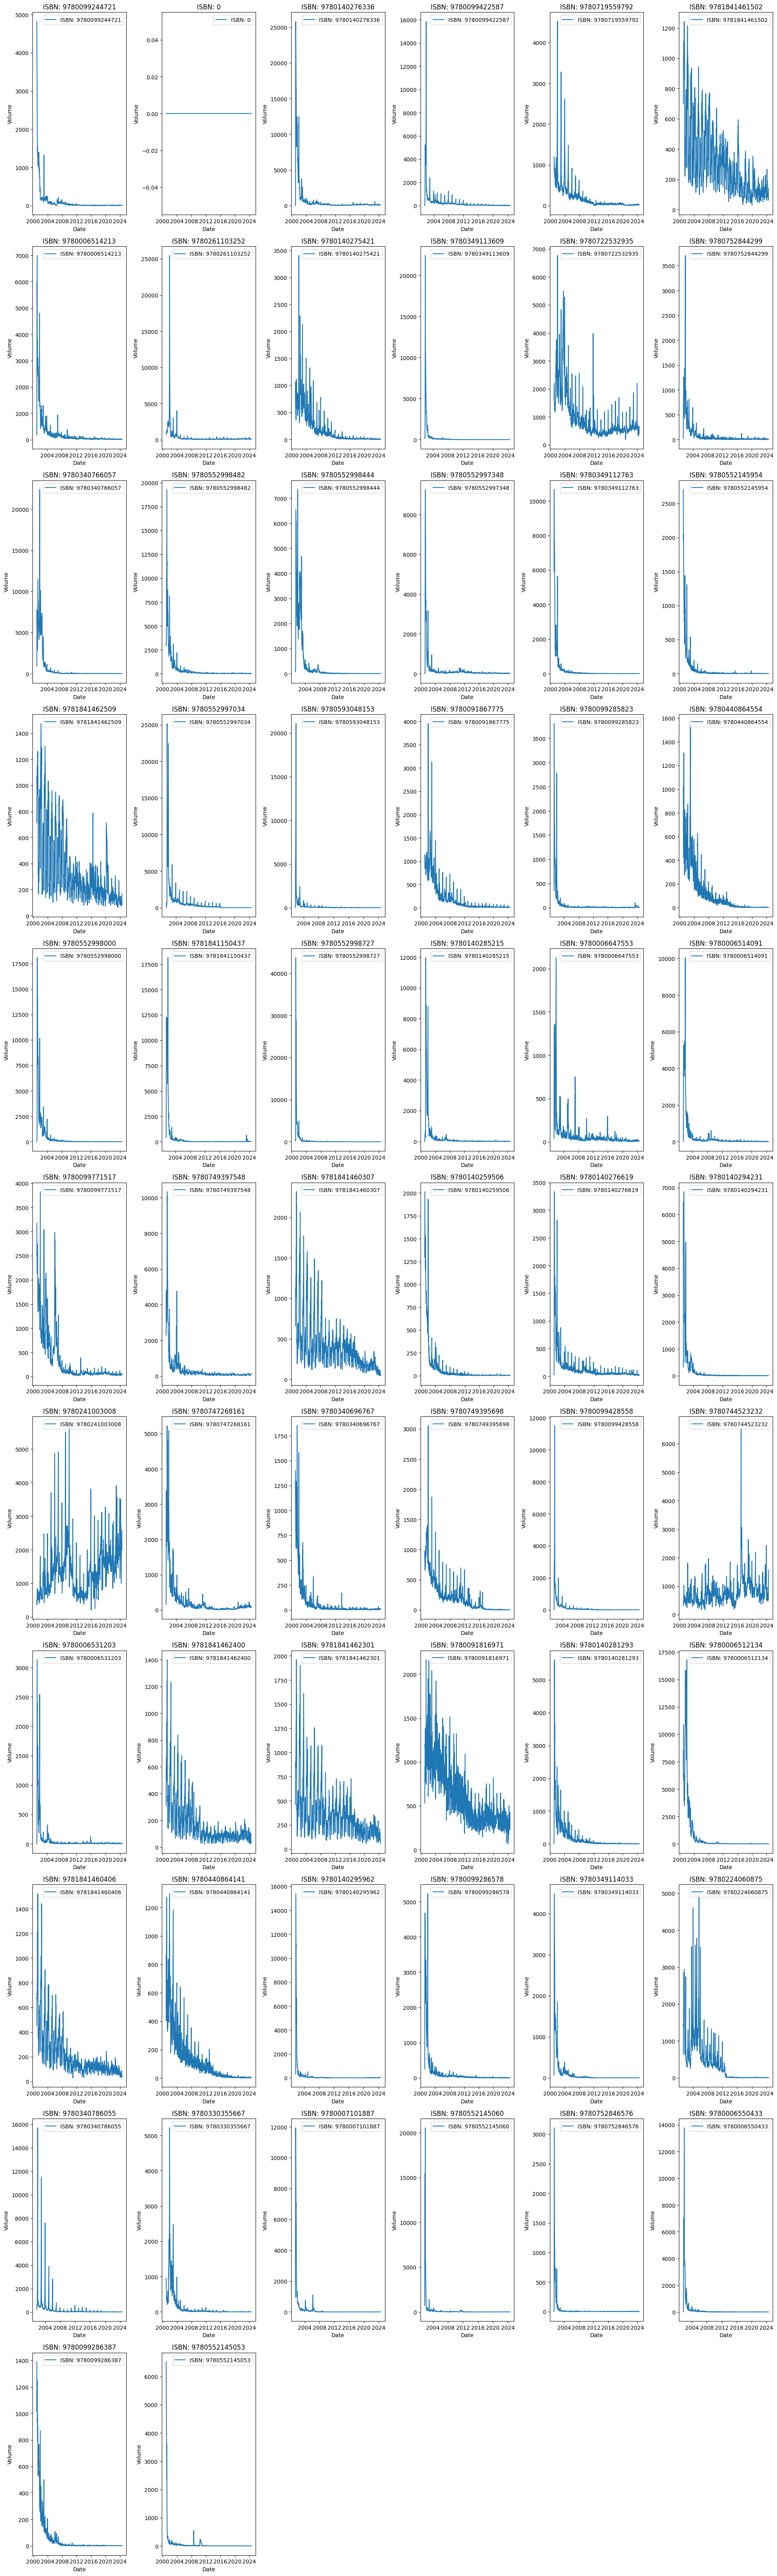

In [ ]:
# Create the figure and axes for subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Loop through each ISBN and plot the data from the original df_UK_weekly dataframe
for idx, isbn in enumerate(isbn_filtered):
    # Filter the original df_UK_weekly to get data for the current ISBN
    df_UK_weekly_isbn = df_UK_weekly_g[df_UK_weekly_g['ISBN'] == isbn]

    # Plot the data
    axes[idx].plot(df_UK_weekly_isbn.index, df_UK_weekly_isbn['Volume'], label=f'ISBN: {isbn}')
    axes[idx].set_title(f'ISBN: {isbn}')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Volume')
    axes[idx].legend()

# Remove unused subplots if there are any
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])

# Adjust layout for better spacing
plt.tight_layout()

In [ ]:
top10 = (
    df_UK_weekly_g.groupby("Title")["Volume"]
    .sum()
    .sort_values(ascending=False)
    .head(10))

top10 = top10.reset_index()

In [ ]:
top10.head(10)

,Title,Volume
0,Harry Potter and the Philosopher's Stone,2625031
1,Harry Potter and the Goblet of Fire,2312477
2,Harry Potter and the Prisoner of Azkaban,1915378
3,Harry Potter and the Chamber of Secrets,1824376
4,"Very Hungry Caterpillar, The",1763001
5,"Gruffalo, The",1464776
6,"Highway Code, The",1281533
7,"Alchemist, The",1166107
8,"Child Called It, A",1107936
9,We're Going on a Bear Hunt,941922


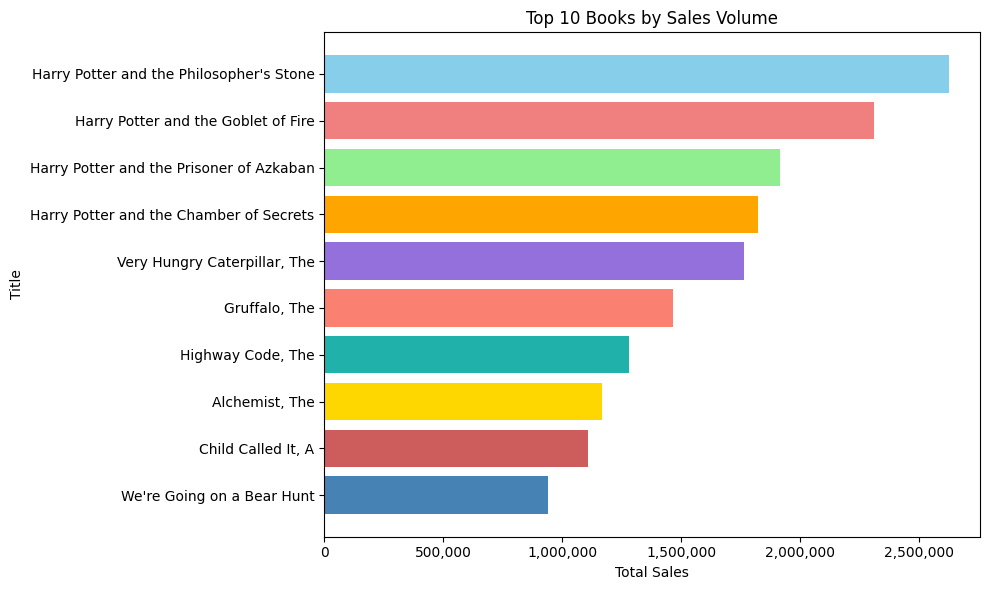

In [ ]:
plt.figure(figsize=(10,6))
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange', 'mediumpurple', 'salmon', 'lightseagreen', 'gold', 'indianred', 'steelblue'] # Define a list of colors
plt.barh(top10["Title"], top10["Volume"], color=colors)
plt.gca().invert_yaxis()
plt.title("Top 10 Books by Sales Volume")
plt.xlabel("Total Sales")
plt.ylabel("Title")
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

Volume has drascically decreesed from 2000 to 2004 before platuoing around 2008 to 2024 in most cases. Some books have a more gradual decline but most show the same downwards trend

We will be focusing on The Very Hungry Caterpillar and The Alchemist for further analysis. In this notebook we will just look at The Alchemist then in a seperate notebook The Very Hungry Caterpillar .

Looking at the data after 2012-01-01

In [ ]:
df_UK_weekly_g.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2001-01-07,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200101,522,2544.07,4.8737,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
2001-01-07,9780003224764,Psychology for AS-level,"Cardwell, Mike & Clark, Liz & Meldrum, Claire",200101,40,482.56,12.0640,12.99,Paperback,Collins Educational,HarperCollins Grp,S2.2T Psychology: Textbooks & Study Guides,S Adult Non-Fiction Specialist
2001-01-07,9780718144395,"Return of the Naked Chef, The","Oliver, Jamie",200101,5742,83782.37,14.5911,20.00,Hardback,Michael Joseph,Penguin Grp,T16.0 Food & Drink: General,T Adult Non-Fiction Trade
2001-01-07,9780552998727,Marrying the Mistress,"Trollope, Joanna",200101,573,4005.18,6.9898,10.99,Paperback,Black Swan,Transworld Grp,F1.1 General & Literary Fiction,F Adult Fiction
2001-01-07,9780115519772,Highway Code,0,200101,6185,9168.94,1.4824,1.49,Paperback,Stationery Office Books,The Stationery Office Grp,T12.2 Driving & The Highway Code,T Adult Non-Fiction Trade


In [ ]:
alchemist_isbns = df_ISBN[df_ISBN['Title'].str.contains('alchemist', case=False, na=False)]['ISBN'].astype(str).unique()

In [ ]:
print("The Alchemist ISBNs:")
print(alchemist_isbns)

The Alchemist ISBNs:
['9780722532935']


In [ ]:
# Apply the date filter to df_UK_weekly
df_UK_weekly_post2012 = df_UK_weekly_g[df_UK_weekly_g.index > '2012-01-01']

# For The Alchemist ISBNs
for isbn in alchemist_isbns:
    volume_alchemist = df_UK_weekly_post2012[df_UK_weekly_post2012['ISBN'] == isbn]['Volume'].sum()
    print(f"Volume for ISBN {isbn} (The Alchemist) after 2012-01-01: {volume_alchemist}")


Volume for ISBN 9780722532935 (The Alchemist) after 2012-01-01: 345907


We will be analysing:

Volume for ISBN 9780722532935 (The Alchemist) after 2012-01-01: 345907

In [ ]:
# Directly filter df_UK_weekly_post2012 for the ISBNs
df_UK_weekly_post2012 = df_UK_weekly_post2012[df_UK_weekly_post2012['ISBN'].isin(['9780722532935'])]

In [ ]:
df_UK_weekly_post2012.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2012-01-08,9780722532935,"Alchemist, The","Coelho, Paulo",201201,518,3601.76,6.9532,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2012-01-15,9780722532935,"Alchemist, The","Coelho, Paulo",201202,533,3610.12,6.7732,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2012-01-22,9780722532935,"Alchemist, The","Coelho, Paulo",201203,475,3105.62,6.5381,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2012-01-29,9780722532935,"Alchemist, The","Coelho, Paulo",201204,514,3431.29,6.6757,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2012-02-05,9780722532935,"Alchemist, The","Coelho, Paulo",201205,591,3929.22,6.6484,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


In [ ]:
df_UK_weekly_post2012.shape

(628, 13)

In [ ]:
df_UK_weekly_post2012['Title'].unique()

array(['Alchemist, The'], dtype=object)

In [ ]:
# sorting the titles to read 'The Alchemist'
df_UK_weekly_post2012['Title'] = df_UK_weekly_post2012['Title'].str.replace(r'^(.*), The$', r'The \1', regex=True)

In [ ]:
df_UK_weekly_post2012['Title'].unique()

array(['The Alchemist'], dtype=object)

In [ ]:
df_UK_weekly_post2012['Volume'].isna().sum()

0

The Alchemist


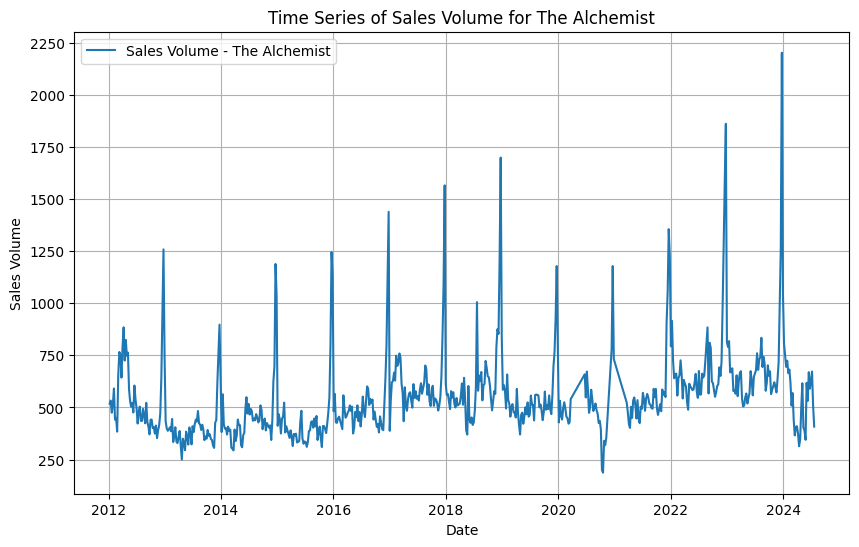

In [ ]:

# List of ISBNs to plot
isbns_to_plot = ['9780722532935']

# Loop through the ISBNs and plot
for isbn in isbns_to_plot:
    # Filter the df_UK_weekly_post2012 by the ISBN
    book_data = df_UK_weekly_post2012[df_UK_weekly_post2012['ISBN'] == isbn]

    # Get the unique title(s) for the ISBN
    title = book_data['Title'].unique()[0]
    print(title)

    # Plot the Volume over Time
    plt.figure(figsize=(10, 6))
    plt.plot(book_data.index, book_data['Volume'], label=f'Sales Volume - {title}')
    plt.title(f'Time Series of Sales Volume for {title}')
    plt.xlabel('Date')
    plt.ylabel('Sales Volume')
    plt.grid(True)
    plt.legend()
    plt.show()


**Monthly**

In [ ]:
# Group by ISBN and resample by month-end, explicitly summing only the 'Volume' column.
book_monthly = df_UK_weekly_post2012.groupby('ISBN').resample('ME').agg({'Volume': 'sum'})

# The result of agg is a MultiIndex Series. Convert it back to a DataFrame and set End_Date as the main index.
book_monthly = book_monthly.reset_index()
book_monthly.set_index('End_Date', inplace=True)

# Sort by index to ensure chronological order
book_monthly.sort_index(inplace=True)

book_monthly.head(5)

,ISBN,Volume
End_Date,,
2012-01-31,9780722532935,2040
2012-02-29,9780722532935,1866
2012-03-31,9780722532935,2813
2012-04-30,9780722532935,3971
2012-05-31,9780722532935,2385


# **Helper Functions**

**Evaluating**

In [ ]:
def evaluate_forecast(actual, forecast):

    mae = mean_absolute_error(actual, forecast)

    rmse = root_mean_squared_error(
        actual,
        forecast
    )

    mape = (
        mean_absolute_percentage_error(
            actual,
            forecast
        ) * 100
    )

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    return mae, rmse, mape

**Graphing**

In [ ]:
#normal plot
def plot_forecast(
    train,
    test,
    forecast,
    title
):

    plt.figure(figsize=(12,6))

    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Actual')
    plt.plot(test.index, forecast, label='Forecast')

    plt.title(title)
    plt.legend()

    plt.show()

In [ ]:
#zoomed in plot
def plot_forecast_zoom(train, test, forecast, title):

    plt.figure(figsize=(12,6))

    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Actual')
    plt.plot(test.index, forecast, label='Forecast')

    plt.title(title)
    plt.legend()

    plt.xlim(pd.Timestamp("2023-01-01"), None)

    plt.show()

**XGBoost**

In [ ]:
def create_lag_features(y, lag=1):
    df = pd.DataFrame({'y': y})
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['y'].shift(i)
    return df.dropna()

In [ ]:
def recursive_forecast(history, horizon, predict_fn):
    preds = []
    history = list(history)
    for _ in range(horizon):
        pred = predict_fn(history)
        preds.append(pred)
        history.append(pred)
    return preds

**LSTM**

In [ ]:
def create_input_sequence(lookback, forecast, squence_data):
  input_sequences = []
  output_sequences = []

  for i in range(lookback, len(squence_data) - forecast + 1):
    input_sequences.append(squence_data[i - lookback: i])
    output_sequences.append(squence_data[i: i + forecast])

  return np.array(input_sequences), np.array(output_sequences)

In [ ]:
def tuned_model(hp):

    model = Sequential()
    model.add(LSTM(hp.Int('input_unit',min_value=4,max_value=128,step=8),return_sequences=True, input_shape=(lookback, 1)))
    for i in range(hp.Int('n_layers', 1, 4)):
        model.add(LSTM(hp.Int(f'lstm_{i}_units',min_value=4,max_value=128,step=8),return_sequences=True))
    model.add(LSTM(hp.Int('layer_2_neurons',min_value=4,max_value=128,step=8)))
    model.add(Dropout(hp.Float('Dropout_rate',min_value=0,max_value=0.5,step=0.1)))
    model.add(Dense(1, activation=hp.Choice('dense_activation',values=['relu', 'sigmoid'],default='relu')))
    model.compile(loss='mean_squared_error', optimizer='adam',metrics = ['mse'])
    return model

# **Decomposition**

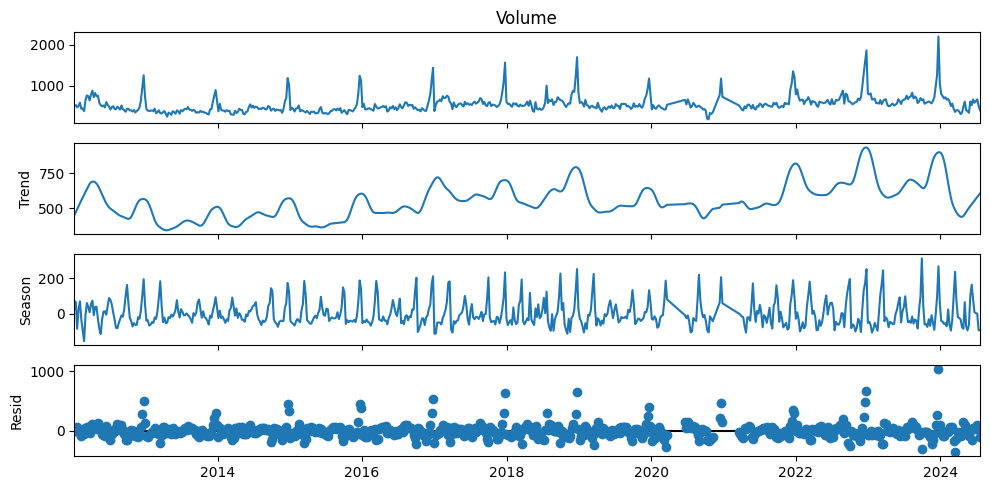

In [ ]:
#STL
stl = STL(df_UK_weekly_post2012['Volume'], period=12)
res = stl.fit()
fig = res.plot()

In [ ]:
#Residuals
residuals = res.resid

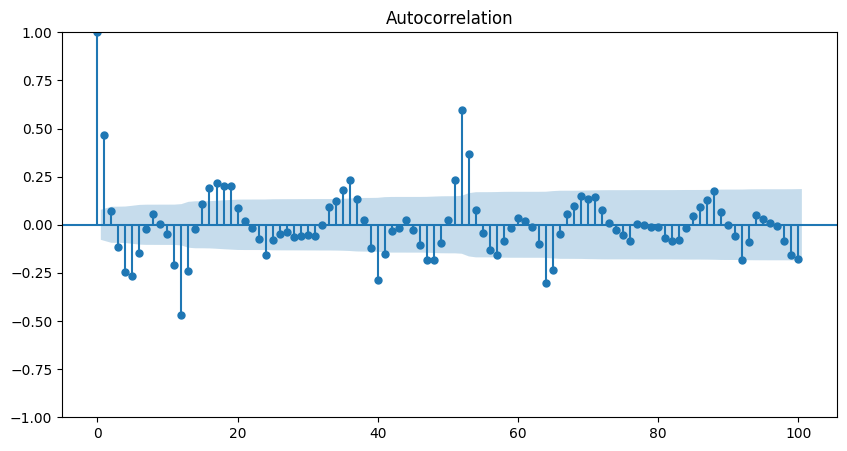

In [ ]:
#ACF
smgraphics.tsa.plot_acf(residuals, lags=100)
plt.show()

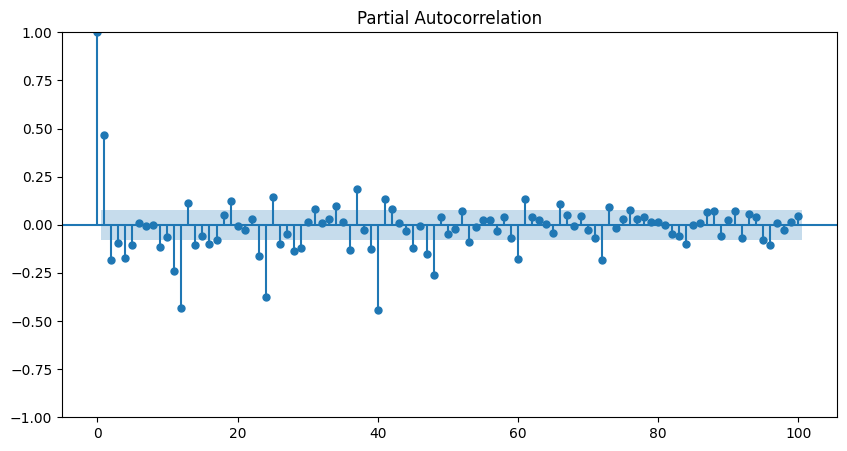

In [ ]:
#PACF
smgraphics.tsa.plot_pacf(residuals, lags=100)
plt.show()

In [ ]:
#Ljung-Box Test
ljungbox = acorr_ljungbox(residuals, lags=12, return_df=True)
print(ljungbox)

       lb_stat     lb_pvalue
1   136.909416  1.262133e-31
2   140.304135  3.414634e-31
3   148.986293  4.359503e-32
4   187.913631  1.487989e-39
5   233.711627  1.712249e-48
6   247.332416  1.523855e-50
7   247.617400  8.905395e-50
8   249.639093  2.054639e-49
9   249.667021  1.172894e-48
10  250.986779  3.366186e-48
11  278.782825  2.555230e-53
12  420.622418  1.616337e-82


In [ ]:
#ADF Test
adf = adf(residuals)
print(f"ADF Statistic: {adf[0]}")
print(f"p-value: {adf[1]}")

ADF Statistic: -7.9891815105301776
p-value: 2.5011318969593452e-12


The Alchemist shows a weaker upward trend, with strong and stable seasonality and residuals centred around zero. This again suggests an additive decomposition.
Similar to The Very Hungry Caterpillar, the ACF and PACF plots show comparable patterns. The results of the ADF and Ljung–Box tests are also consistent with those observed for The Very Hungry Caterpillar.


# **Auto ARIMA**

In [ ]:
#split the data
ts_train = df_UK_weekly_post2012['Volume'][:-32]
ts_test = df_UK_weekly_post2012['Volume'][-32:]

In [ ]:
ts_train

,Volume
End_Date,
2012-01-08,518
2012-01-15,533
2012-01-22,475
2012-01-29,514
2012-02-05,591
...,...
2023-11-12,599
2023-11-19,572
2023-11-26,637


In [ ]:
ts_test

,Volume
End_Date,
2023-12-17,1260
2023-12-24,2201
2023-12-31,1050
2024-01-07,806
2024-01-14,748
2024-01-21,695
2024-01-28,724
2024-02-04,664
2024-02-11,682


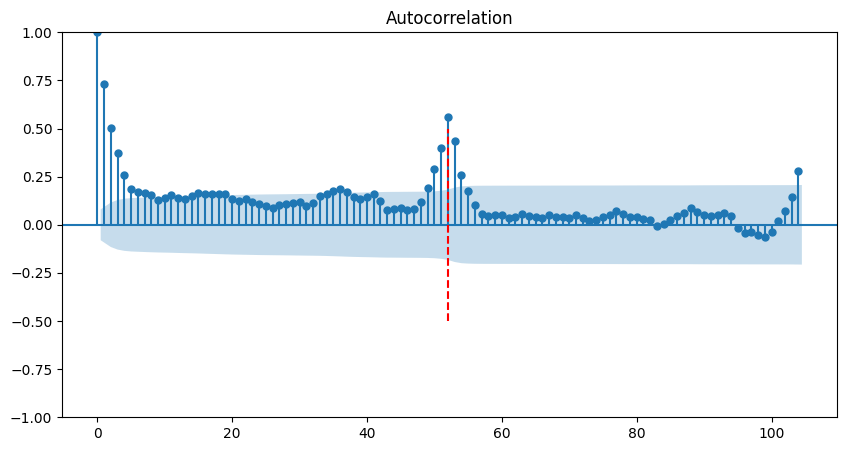

In [ ]:
#Find the seasonal period
smgraphics.tsa.plot_acf(ts_train, lags=104)
plt.vlines(x=52, ymin=-0.5, ymax=0.5, colors='red', linestyle='--')
plt.show()

In [ ]:
#Auto ARIMA
auto_arima = auto_arima(ts_train,
                                    start_p=0,
                                    start_q=0,
                                    max_p=1,
                                    max_q=1,
                                    start_P=0,
                                    start_Q=0,
                                    max_P=1,
                                    max_Q=1,
                                    D=1,
                                    information_criterion='aicc',
                                    seasonal=True,
                                    stepwise=True,
                                    suppress_warnings=True,
                                    error_action='ignore',
                                    m=52,
                                    trace=True)
print("\nAuto ARIMA The Alchemist model summary:")
print(auto_arima.summary())

Performing stepwise search to minimize aicc
 ARIMA(0,1,0)(0,1,0)[52]             : AICC=6779.135, Time=2.74 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AICC=6729.011, Time=12.31 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AICC=6710.933, Time=30.42 sec
 ARIMA(0,1,1)(0,1,0)[52]             : AICC=6736.572, Time=1.44 sec
 ARIMA(0,1,1)(1,1,1)[52]             : AICC=inf, Time=47.85 sec
 ARIMA(0,1,1)(1,1,0)[52]             : AICC=6714.226, Time=7.53 sec
 ARIMA(0,1,0)(0,1,1)[52]             : AICC=6746.983, Time=48.85 sec
 ARIMA(1,1,1)(0,1,1)[52]             : AICC=6664.858, Time=45.30 sec
 ARIMA(1,1,1)(0,1,0)[52]             : AICC=6693.111, Time=3.53 sec
 ARIMA(1,1,1)(1,1,1)[52]             : AICC=inf, Time=115.77 sec
 ARIMA(1,1,1)(1,1,0)[52]             : AICC=6668.374, Time=32.28 sec
 ARIMA(1,1,0)(0,1,1)[52]             : AICC=6725.885, Time=26.79 sec
 ARIMA(1,1,1)(0,1,1)[52] intercept   : AICC=6666.656, Time=61.87 sec

Best model:  ARIMA(1,1,1)(0,1,1)[52]          
Total fit time: 436.717 

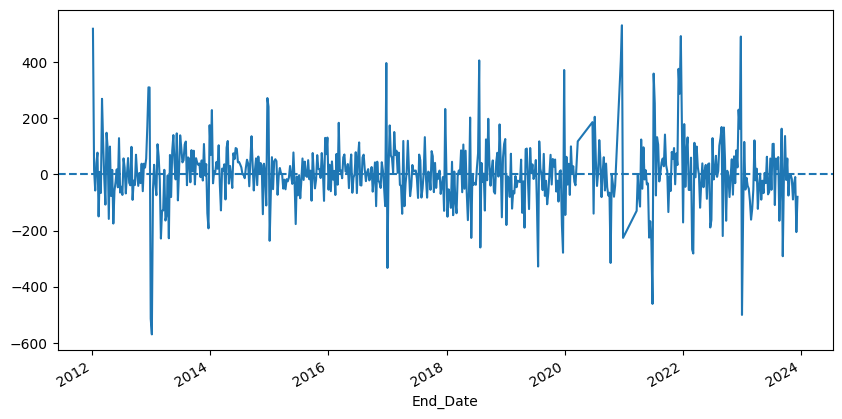

In [ ]:
#Find the residuals for the best model
residuals_aa = auto_arima.resid()

#plot the residuals
residuals_aa.plot()
plt.axhline(0, linestyle='--')
plt.show()

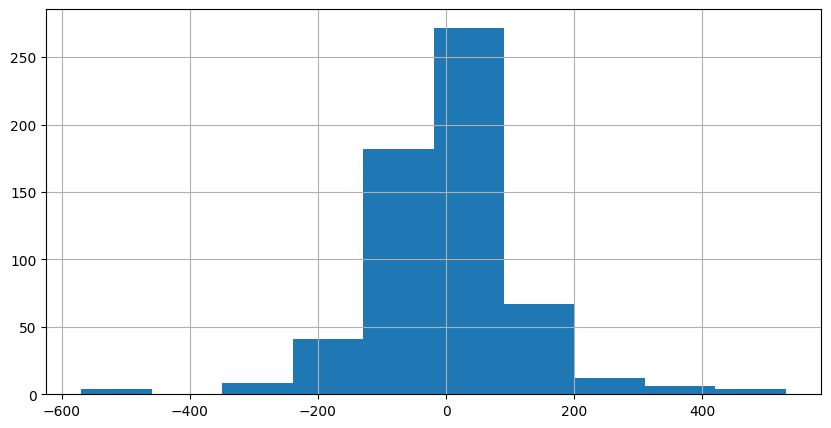

In [ ]:
#Histogram of residuals
residuals_aa.hist()
plt.show()

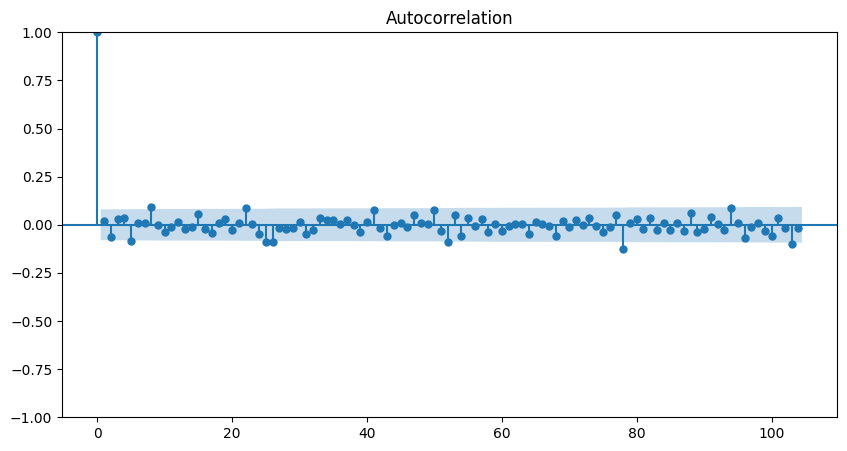

In [ ]:
#ACF of residuals
smgraphics.tsa.plot_acf(residuals_aa, lags=104)
plt.show()

In [ ]:
#Ljung-box Test on Residuals
ljungbox_aa = acorr_ljungbox(residuals_aa, lags=12, return_df=True)
print(ljungbox_aa)

      lb_stat  lb_pvalue
1    0.264094   0.607321
2    2.594037   0.273346
3    3.156239   0.368158
4    3.927796   0.415866
5    8.324396   0.139241
6    8.370330   0.212208
7    8.412437   0.297633
8   13.391356   0.099075
9   13.393462   0.145596
10  14.174504   0.165180
11  14.282392   0.217760
12  14.382234   0.276968


Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 52)

The Alchemist does not perform as well, with a higher MAPE score of 25.79%. However, the Ljung–Box test returns a p-value of 0.13, indicating that the residuals are mostly noise and suggesting a better model fit in terms of residual independence.

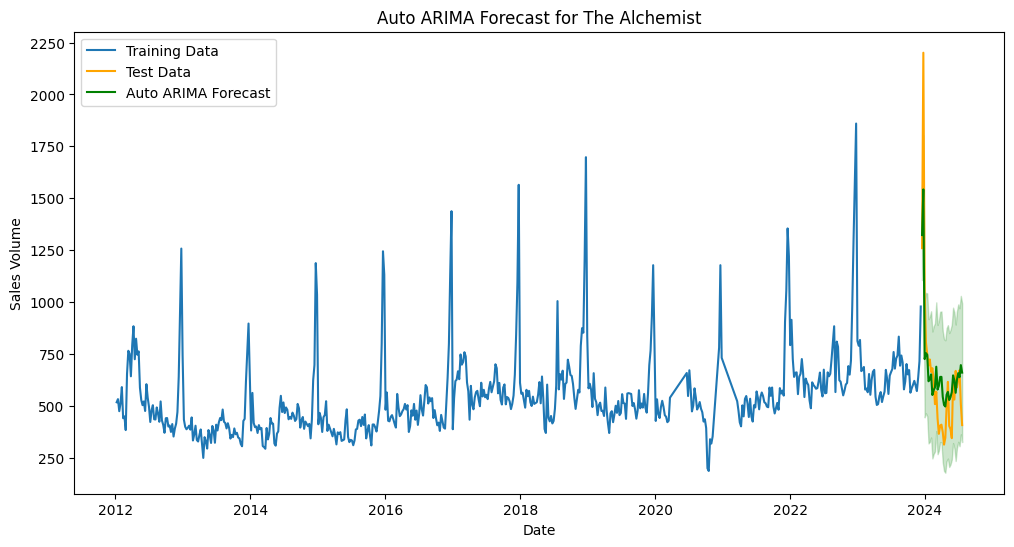

In [ ]:
#Calculate forceasts and confidence intervals for the auto ARIMA model.
auto_arima_forecast = auto_arima.predict(n_periods=32)
auto_arima_ci = auto_arima.predict(n_periods=32, return_conf_int=True)[1]

#create a date index for the forecasts that matches the test set.
forecast_index = ts_test.index

#Plot the results.
plt.figure(figsize=(12, 6))
plt.plot(ts_train.index, ts_train, label='Training Data')
plt.plot(ts_test.index, ts_test, label='Test Data', color='orange')
plt.plot(forecast_index, auto_arima_forecast, label='Auto ARIMA Forecast', color='green')
plt.fill_between(forecast_index, auto_arima_ci[:, 0], auto_arima_ci[:, 1], color='green', alpha=0.2)
plt.title('Auto ARIMA Forecast for The Alchemist')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.show()

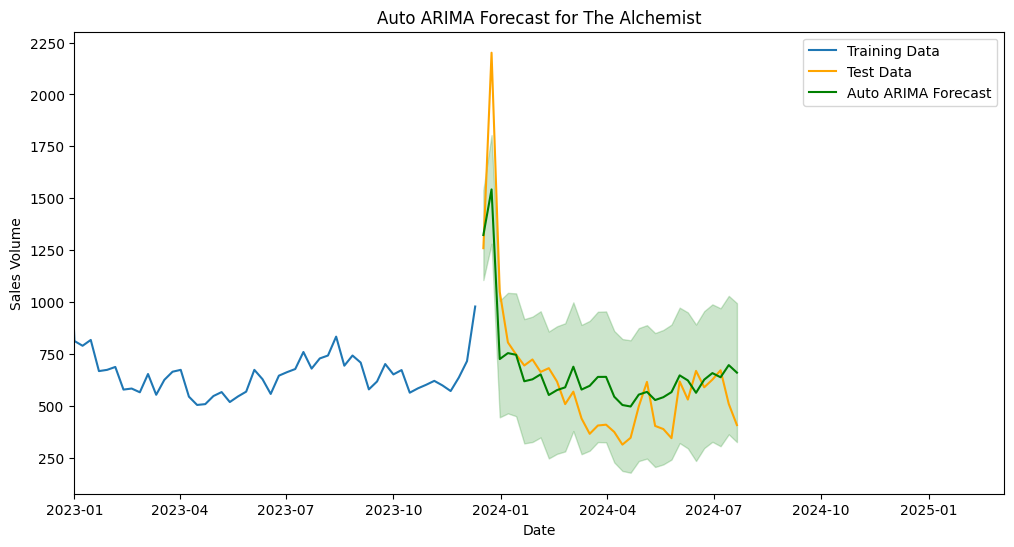

In [ ]:
#Plot the results.
plt.figure(figsize=(12, 6))
plt.plot(ts_train.index, ts_train, label='Training Data')
plt.plot(ts_test.index, ts_test, label='Test Data', color='orange')
plt.plot(forecast_index, auto_arima_forecast, label='Auto ARIMA Forecast', color='green')
plt.fill_between(forecast_index, auto_arima_ci[:, 0], auto_arima_ci[:, 1], color='green', alpha=0.2)
plt.xlim(pd.Timestamp("2023-01-01", None))
plt.title('Auto ARIMA Forecast for The Alchemist')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.show()

In [ ]:
#Evaluate
evaluate_forecast(ts_test, auto_arima_forecast)

MAE: 136.61
RMSE: 184.07
MAPE: 25.79%


(136.61353088451895, 184.06662252925972, 25.790482322374086)

# **XGBoost**

In [ ]:
#Hyper tuning parameters
window_lengths = [12, 26, 52]

param_grid = {
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200]
}

In [ ]:
results_xgb = []

tscv_xgb = TimeSeriesSplit(n_splits=5)

for window_length in window_lengths:
  lagged_data = create_lag_features(df_UK_weekly_post2012['Volume'], lag=window_length)
  train_lagged = lagged_data.loc[lagged_data.index <= ts_train.index[-1]]

  x_train_xbg = train_lagged.drop(columns='y')
  y_train_xbg = train_lagged['y']

  for max_depth in param_grid['max_depth']:
    for learning_rate in param_grid['learning_rate']:
      for n_estimators in param_grid['n_estimators']:

        cv_maes = []

        for train_index, test_index in tscv_xgb.split(x_train_xbg):

          x_train_xbg_cv, x_test_xbg_cv = x_train_xbg.iloc[train_index], x_train_xbg.iloc[test_index]
          y_train_xbg_cv, y_test_xbg_cv = y_train_xbg.iloc[train_index], y_train_xbg.iloc[test_index]

          xgb_model = XGBRegressor(objective='reg:absoluteerror', max_depth=max_depth, learning_rate=learning_rate, n_estimators=n_estimators, random_state=seed)
          xgb_model.fit(x_train_xbg_cv, y_train_xbg_cv)

          y_pred_xbg_cv = xgb_model.predict(x_test_xbg_cv)

          cv_maes.append(mean_absolute_error(y_test_xbg_cv, y_pred_xbg_cv))

        results_xgb.append({
            'window_length': window_length,
            'max_depth': max_depth,
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'cv_mae': np.mean(cv_maes)
        })

In [ ]:
#Best Model
results_xgb_df = pd.DataFrame(results_xgb)

best_params_xgb = results_xgb_df.loc[results_xgb_df['cv_mae'].idxmin()]

print("Best Hyperparameters for The Alchemist:")
print(best_params_xgb)

Best Hyperparameters for The Alchemist:
window_length     12.000000
max_depth          4.000000
learning_rate      0.050000
n_estimators     200.000000
cv_mae            77.699354
Name: 5, dtype: float64


In [ ]:
best_window_xgb= int(best_params_xgb['window_length'])

lagged_data_xgb= create_lag_features(df_UK_weekly_post2012['Volume'], lag=best_window_xgb)
train_lagged_xgb = lagged_data_xgb.loc[lagged_data_xgb.index <= ts_train.index[-1]]

x_train_best_xbg = train_lagged_xgb.drop(columns='y')
y_train_best_xbg = train_lagged_xgb['y']

In [ ]:
#Fit the model
best_xgb_model = XGBRegressor(objective='reg:squarederror', max_depth=int(best_params_xgb['max_depth']), learning_rate=best_params_xgb['learning_rate'], n_estimators=int(best_params_xgb["n_estimators"]), random_state=seed)
best_xgb_model.fit(x_train_best_xbg, y_train_best_xbg)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Forecast
def predict_next_xgb(history):
    x_input = np.array(history[-1:-best_window_xgb-1:-1]).reshape(1, -1)
    return best_xgb_model.predict(x_input)[0]

forecast_best_xgb = recursive_forecast(ts_train, 32, predict_next_xgb)

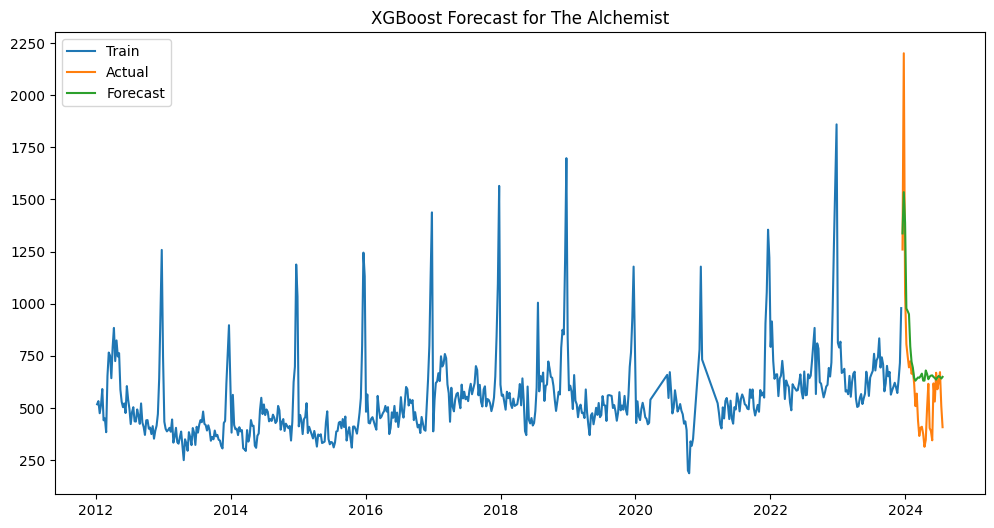

In [ ]:
#plot
plot_forecast(ts_train, ts_test, forecast_best_xgb, 'XGBoost Forecast for The Alchemist')

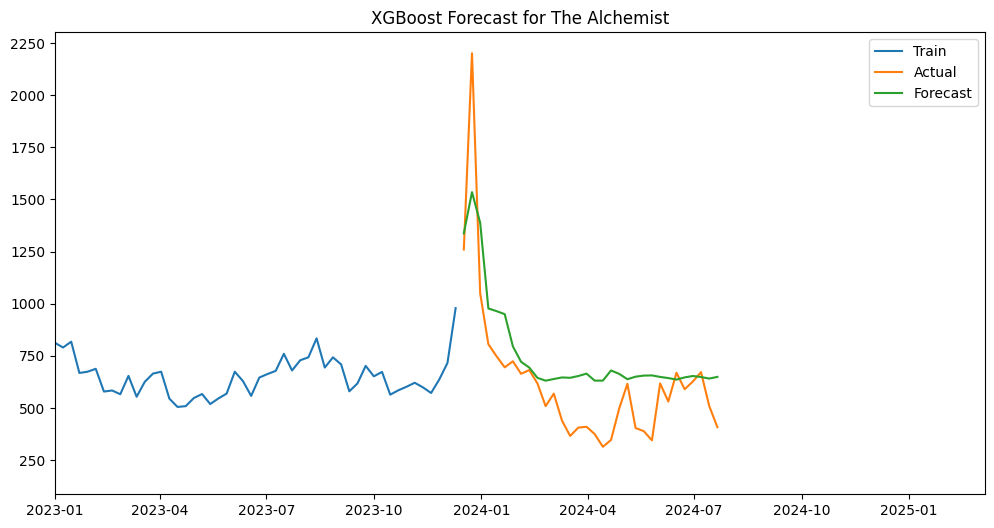

In [ ]:
#zoomed plot
plot_forecast_zoom(ts_train, ts_test, forecast_best_xgb, 'XGBoost Forecast for The Alchemist')

In [ ]:
#Evaluate
evaluate_forecast(ts_test, forecast_best_xgb)

MAE: 176.39
RMSE: 224.22
MAPE: 34.93%


(176.389497756958, 224.22433030885264, 34.92588754551878)

For The Alchemist, the model converges early but fails to capture the lower values observed in the test data. This results in a less accurate representation of the series’ variability.

# **LSTM**

In [ ]:
#Normalise the data
scaler = MinMaxScaler()
scaler.fit(ts_train.values.reshape(-1, 1))
ts_train_scaled = scaler.transform(ts_train.values.reshape(-1, 1))
ts_test_scaled = scaler.transform(ts_test.values.reshape(-1, 1))

In [ ]:
lookback = 52

In [ ]:
x, y = create_input_sequence(lookback, 1, ts_train_scaled)

In [ ]:
print(x.shape)
print(y.shape)

(544, 52, 1)
(544, 1, 1)


In [ ]:
#convert to numpy
x = np.array(x)
y = np.array(y)

In [ ]:
x_train_lstm = x[:-32]
y_train_lstm = y[:-32]
x_test_lstm = x[-32:]
y_test_lstm = y[-32:]

In [ ]:
x_train_lstm.reshape((x_train_lstm.shape[0], x_train_lstm.shape[1], 1))
x_test_lstm.reshape((x_test_lstm.shape[0], x_test_lstm.shape[1], 1))

array([[[0.24745965],
        [0.24267782],
        [0.23670054],
        ...,
        [0.1900777 ],
        [0.19246862],
        [0.21578004]],

       [[0.24267782],
        [0.23670054],
        [0.23849372],
        ...,
        [0.19246862],
        [0.21578004],
        [0.22713688]],

       [[0.23670054],
        [0.23849372],
        [0.25821877],
        ...,
        [0.21578004],
        [0.22713688],
        [0.19844591]],

       ...,

       [[0.3173939 ],
        [0.47340108],
        [0.66347878],
        ...,
        [0.25941423],
        [0.2462642 ],
        [0.23012552]],

       [[0.47340108],
        [0.66347878],
        [0.8350269 ],
        ...,
        [0.2462642 ],
        [0.23012552],
        [0.26897788]],

       [[0.66347878],
        [0.8350269 ],
        [1.        ],
        ...,
        [0.23012552],
        [0.26897788],
        [0.31619845]]])

In [ ]:
tuner = kt.RandomSearch(
    tuned_model,
    objective='mse',
    max_trials=10,
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='sales_forecast_tuned',
    seed=seed
)

In [ ]:
tuner.search(
    x=x_train_lstm,
    y=y_train_lstm,
    epochs=20,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

Trial 10 Complete [00h 00m 42s]
mse: 0.010650926269590855

Best mse So Far: 0.010650926269590855
Total elapsed time: 00h 07m 50s


In [ ]:
best_lstm_model = tuner.get_best_models(num_models=1)[0]

best_hp_lstm_model = tuner.get_best_hyperparameters(1)[0]

print(f"Best Hyperparameters for The Alchemist:", best_hp_lstm_model.values)

Best Hyperparameters for The Alchemist: {'input_unit': 28, 'n_layers': 1, 'lstm_0_units': 36, 'layer_2_neurons': 116, 'Dropout_rate': 0.4, 'dense_activation': 'relu', 'lstm_1_units': 4, 'lstm_2_units': 28, 'lstm_3_units': 116}


In [ ]:
window_lstm = x_train_lstm[-1].copy()

forecast_lstm = []

for i in range(32):

  predictions_lstm = best_lstm_model.predict(window_lstm.reshape((1, lookback, 1)))

  forecast_lstm.append(predictions_lstm)

  window_lstm = np.vstack((window_lstm[1:], predictions_lstm))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━

In [ ]:
forecast_lstm_inverse = scaler.inverse_transform(np.array(forecast_lstm).reshape(-1,1))

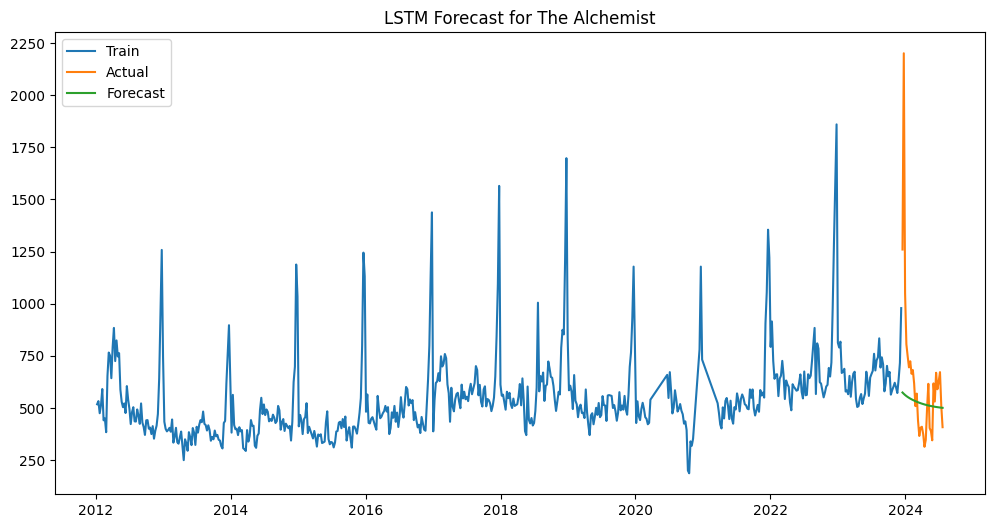

In [ ]:
plot_forecast(ts_train, ts_test, forecast_lstm_inverse, 'LSTM Forecast for The Alchemist')

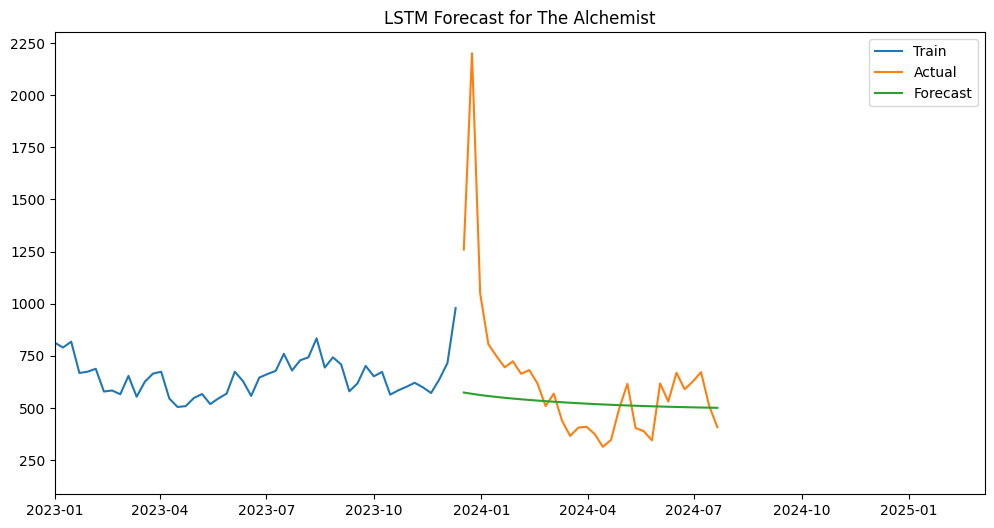

In [ ]:
plot_forecast_zoom(ts_train, ts_test, forecast_lstm_inverse, 'LSTM Forecast for The Alchemist')

In [ ]:
#Evaluate
evaluate_forecast(ts_test, forecast_lstm_inverse)

MAE: 195.83
RMSE: 348.45
MAPE: 27.15%


(195.8251953125, 348.446044921875, 27.146920561790466)

In both cases, the LSTM model produces a smooth forecast that underrepresents the seasonal variations present in the data. This behaviour is similar to that observed with XGBoost, although XGBoost performs better both visually and in terms of MAPE score.

# **Sequential Hybrid**

In [ ]:
#Split the residuals from the SARIMA model
ts_train_sh = residuals_aa[:-32]
ts_test_sh = residuals_aa[-32:]

# Use a separate scaler for the SARIMA residuals
scaler_residuals = MinMaxScaler()
sarima_resid_scaled = scaler_residuals.fit_transform(ts_train_sh.values.reshape(-1, 1))

# Create input sequences for the LSTM on residuals
x_res, y_res = create_input_sequence(lookback, 1, sarima_resid_scaled)

# Perform KerasTuner search for the LSTM on residuals
# Define the directory and project name
tuner_dir_hybrid = 'lstm_tuning_hybrid'
project_name_hybrid = 'sales_forecast_hybrid'
full_path_hybrid = os.path.join(tuner_dir_hybrid, project_name_hybrid)

# Remove the existing KerasTuner project directory to force a fresh search.
if os.path.exists(full_path_hybrid):
    shutil.rmtree(full_path_hybrid)

tuner_s_hybrid = kt.RandomSearch(
    tuned_model,
    objective='mse',
    max_trials=10,
    executions_per_trial=1,
    directory=tuner_dir_hybrid,
    project_name=project_name_hybrid,
    seed=seed
)

tuner_s_hybrid.search(
    x=x_res,
    y=y_res,
    epochs=20,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

best_s_hybrid_model = tuner_s_hybrid.get_best_models(num_models=1)[0]
best_hp_s_hybrid = tuner_s_hybrid.get_best_hyperparameters(1)[0]

print(f"Best Hyperparameters for The Alchemist (tuned Sequential hybrid model):", best_hp_s_hybrid.values)

# Train the best Sequencial hybrid LSTM model residuals
history_s_hybrid = best_s_hybrid_model.fit(x_res, y_res, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Forecast the residuals using the trained LSTM model
window_s_hybrid = x_res[-1].copy()
forecast_s_hybrid = []

for i in range(32):
  predictions_s_hybrid = best_s_hybrid_model.predict(window_s_hybrid.reshape((1, lookback, 1)), verbose=1)
  forecast_s_hybrid.append(predictions_s_hybrid)
  window_s_hybrid = np.vstack((window_s_hybrid[1:], predictions_s_hybrid))

# Inverse transform the LSTM residual forecasts using the scaler for residuals
forecast_s_hybrid_unscaled = scaler_residuals.inverse_transform(np.array(forecast_s_hybrid).reshape(-1,1))

# Create a Pandas Series with the correct index for the LSTM residual forecasts
forecast_s_hybrid_series = pd.Series(forecast_s_hybrid_unscaled.flatten(), index=ts_test.index)

# Ensure auto_arima_forecast has the same index as ts_test for correct element-wise addition
auto_arima_forecast_aligned = pd.Series(auto_arima_forecast.values, index=ts_test.index)

# Combine SARIMA forecast with LSTM residual forecast
combined_s_hybrid_forecast = auto_arima_forecast_aligned + forecast_s_hybrid_series

Trial 10 Complete [00h 00m 45s]
mse: 0.010397610254585743

Best mse So Far: 0.008592136204242706
Total elapsed time: 00h 08m 18s
Best Hyperparameters for The Alchemist (tuned Sequential hybrid model): {'input_unit': 68, 'n_layers': 1, 'lstm_0_units': 60, 'layer_2_neurons': 28, 'Dropout_rate': 0.4, 'dense_activation': 'sigmoid'}
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0197 - val_mse: 0.0197
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0195 - val_mse: 0.0195
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0195 - val_mse: 0.0195
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0086 - mse: 0.0086 - val_loss: 0.0195 - val_mse: 0.0195
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0089 - mse: 0.0089 - val_loss: 0.0195 - val_mse: 0.0195
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0087 - mse: 0.0087 - v

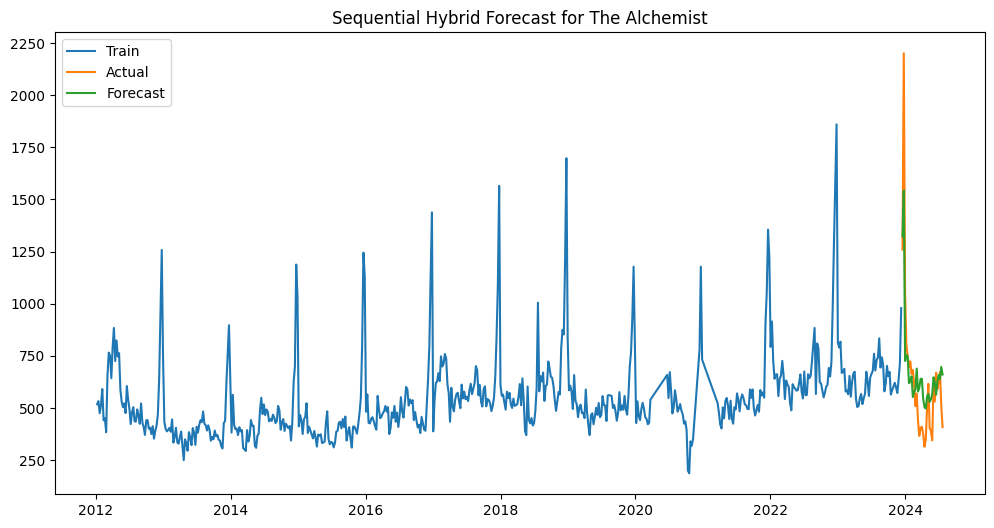

In [ ]:
plot_forecast(ts_train, ts_test, combined_s_hybrid_forecast, 'Sequential Hybrid Forecast for The Alchemist')

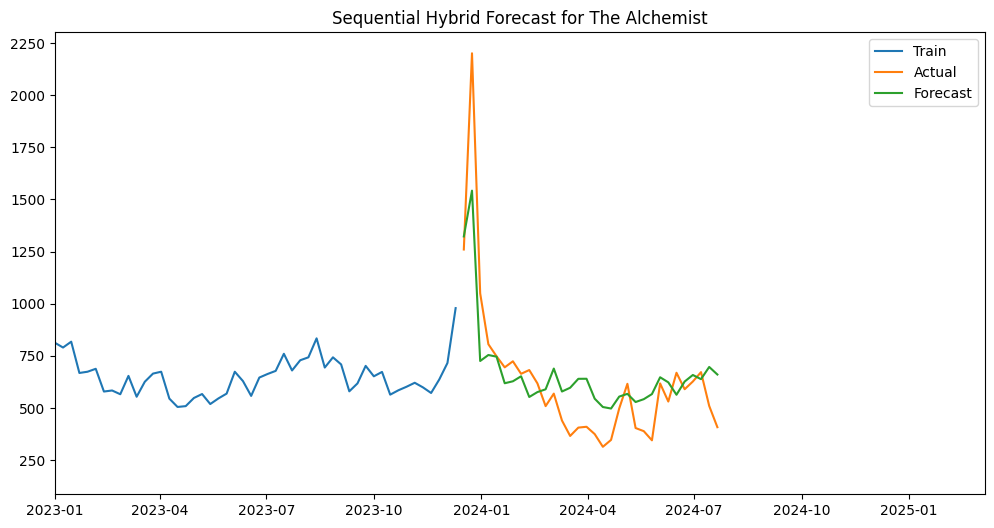

In [ ]:
plot_forecast_zoom(ts_train, ts_test, combined_s_hybrid_forecast, 'Sequential Hybrid Forecast for The Alchemist')

In [ ]:
#Evaluate
evaluate_forecast(ts_test, combined_s_hybrid_forecast)

MAE: 136.67
RMSE: 184.14
MAPE: 25.80%


(136.667192758345, 184.1444769155659, 25.795463623751537)

Using a hybrid SARIMA–LSTM model, the results are notably improved compared to the standalone machine learning and deep learning approaches, with better capture of both trend and seasonal components. However, the MAPE scores are only marginally better than those achieved by the Auto ARIMA models alone

# **Parallel Hybrid**

In [ ]:
combined_forecast_values = (auto_arima_forecast.values + forecast_lstm_inverse.flatten()) / 2
parallel_forecast = pd.Series(combined_forecast_values, index=forecast_index)

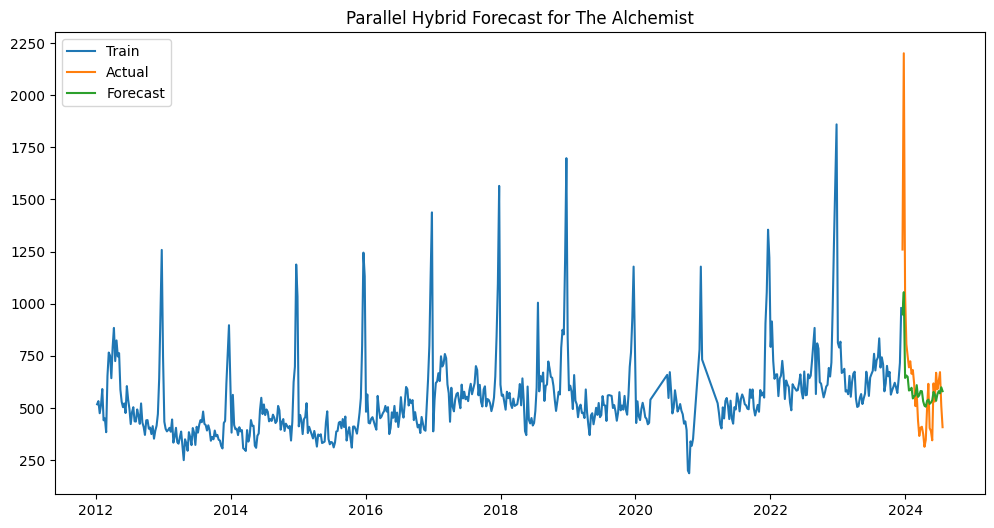

In [ ]:
plot_forecast(ts_train, ts_test, parallel_forecast, 'Parallel Hybrid Forecast for The Alchemist')

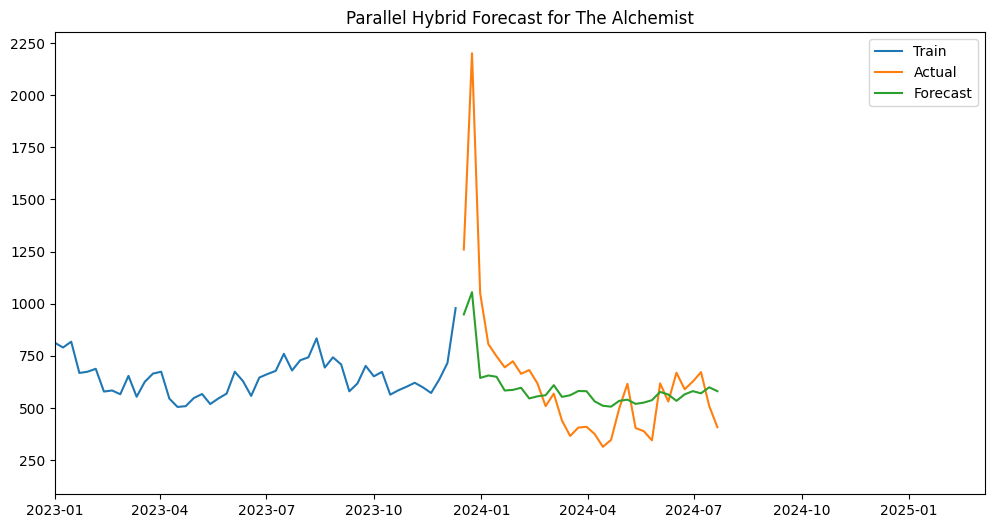

In [ ]:
plot_forecast_zoom(ts_train, ts_test, parallel_forecast, 'Parallel Hybrid Forecast for The Alchemist')

In [ ]:
#Evaluate
evaluate_forecast(ts_test, parallel_forecast)

MAE: 158.93
RMSE: 251.02
MAPE: 25.40%


(158.92878473752046, 251.01938968684476, 25.398535040075654)

In [ ]:
#Best Weights
best_weight = None
best_mae = float('inf')

for w in np.arange(0, 1.1, 0.05):
  combined_forecast_values = (w * auto_arima_forecast.values + (1 - w) * np.array(forecast_lstm).flatten())
  mae_parallel = mean_absolute_error(ts_test, combined_forecast_values)

  if mae_parallel < best_mae:
    best_mae = mae_parallel
    best_weight = w

print(f"Best Weight for The Very Alchemist: {best_weight}")
print(f"Best MAE for The Very Alchemist: {best_mae}")

Best Weight for The Very Alchemist: 0.9500000000000001
Best MAE for The Very Alchemist: 130.604682253378


In [ ]:
best_parallel_hybrid = (
    best_weight * auto_arima_forecast.values
    + (1 - best_weight) * np.array(forecast_lstm).flatten()
)

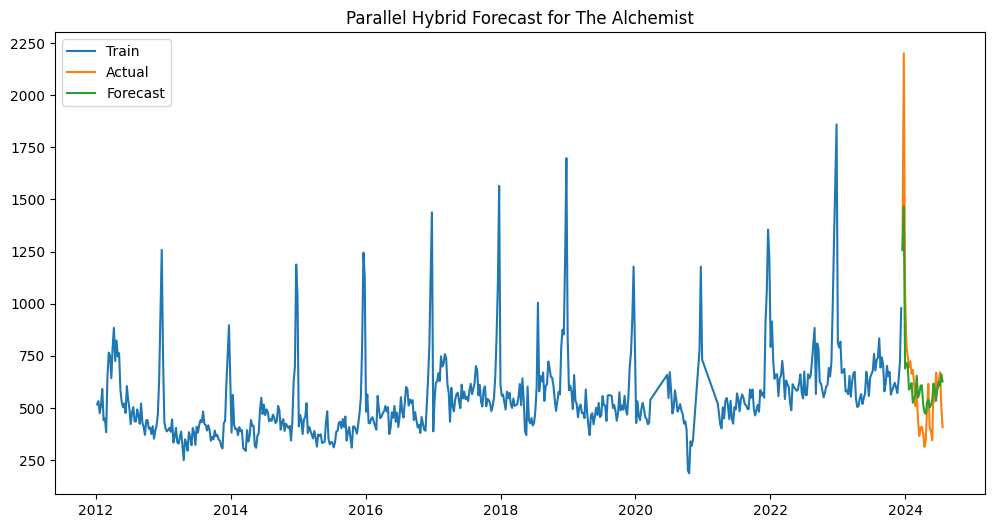

In [ ]:
plot_forecast(ts_train, ts_test, best_parallel_hybrid, 'Parallel Hybrid Forecast for The Alchemist')

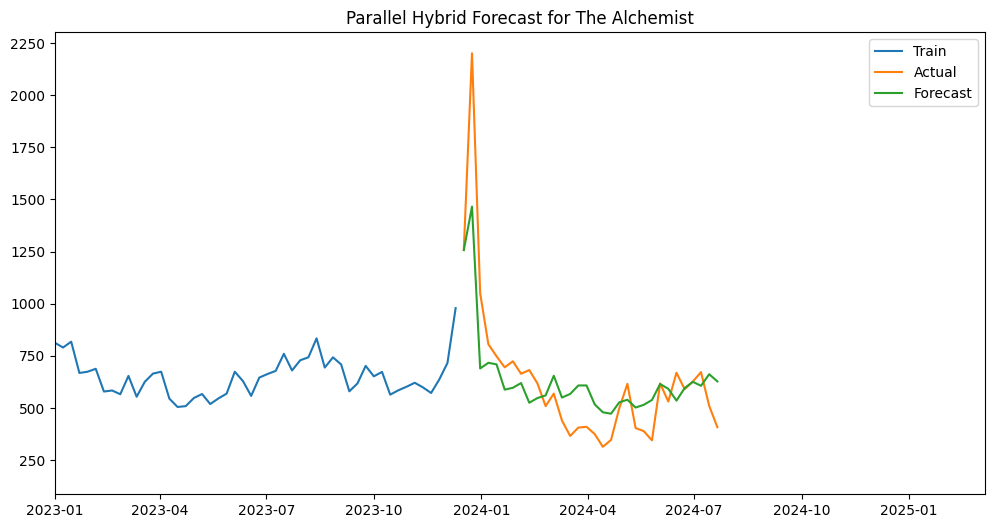

In [ ]:
plot_forecast_zoom(ts_train, ts_test, best_parallel_hybrid, 'Parallel Hybrid Forecast for The Alchemist')

In [ ]:
#Evaluate
evaluate_forecast(ts_test, best_parallel_hybrid)

MAE: 130.60
RMSE: 186.43
MAPE: 23.31%


(130.604682253378, 186.43455437750072, 23.311042962345258)

When comparing approaches, combining SARIMA and LSTM and applying weighted tuning produces better results than using SARIMA outputs alone to train an LSTM model. In both cases, the forecasts closely follow the overall pattern of the test data.

# **SARIMA (Monthly)**

In [ ]:
#split the data
monthly_ts_train = book_monthly['Volume'][:-8]
monthly_ts_test = book_monthly['Volume'][-8:]

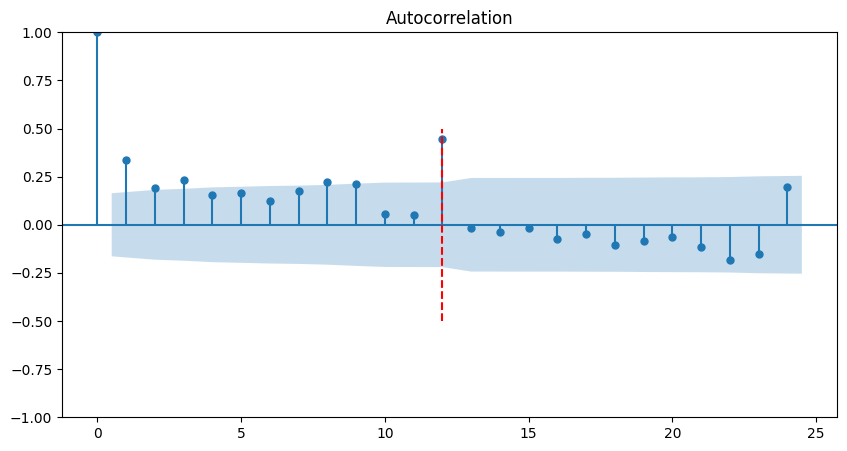

In [ ]:
#Find the seasonal period
smgraphics.tsa.plot_acf(monthly_ts_train, lags=24)
plt.vlines(x=12, ymin=-0.5, ymax=0.5, colors='red', linestyle='--')
plt.show()

In [ ]:
#Monthly Model
#Best model:  ARIMA(1,1,1)(0,1,1)[52]

monthly_sarima = SARIMAX(monthly_ts_train, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))

monthly_sarima_fit = monthly_sarima.fit()

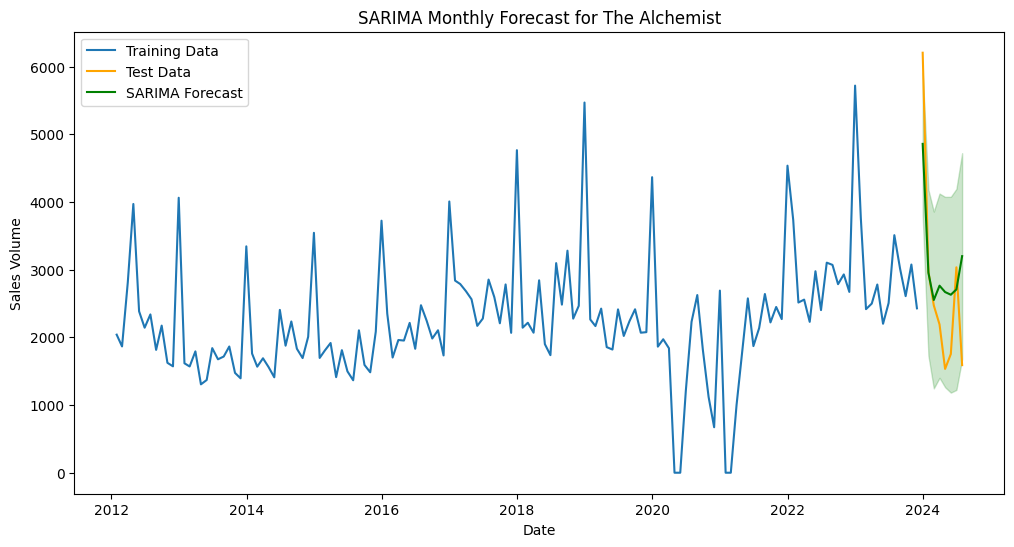

In [ ]:
forecast_monthly_sarima_index = monthly_ts_test.index

sarima_forecast_result = monthly_sarima_fit.get_forecast(steps=len(monthly_ts_test))
forecast_monthly_sarima = sarima_forecast_result.predicted_mean

# Get confidence intervals for the same number of steps as the forecast.
forecast_monthly_sarima_ci = sarima_forecast_result.conf_int()

#create a date index for the forecasts that matches the test set.
forecast_index = monthly_ts_test.index

#plot the results
plt.figure(figsize=(12, 6))
plt.plot(monthly_ts_train.index, monthly_ts_train, label='Training Data')
plt.plot(monthly_ts_test.index, monthly_ts_test, label='Test Data', color='orange')
plt.plot(forecast_monthly_sarima_index, forecast_monthly_sarima, label='SARIMA Forecast', color='green')
plt.fill_between(forecast_monthly_sarima_index, forecast_monthly_sarima_ci.iloc[:, 0], forecast_monthly_sarima_ci.iloc[:, 1], color='green', alpha=0.2)
plt.title('SARIMA Monthly Forecast for The Alchemist')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.show()

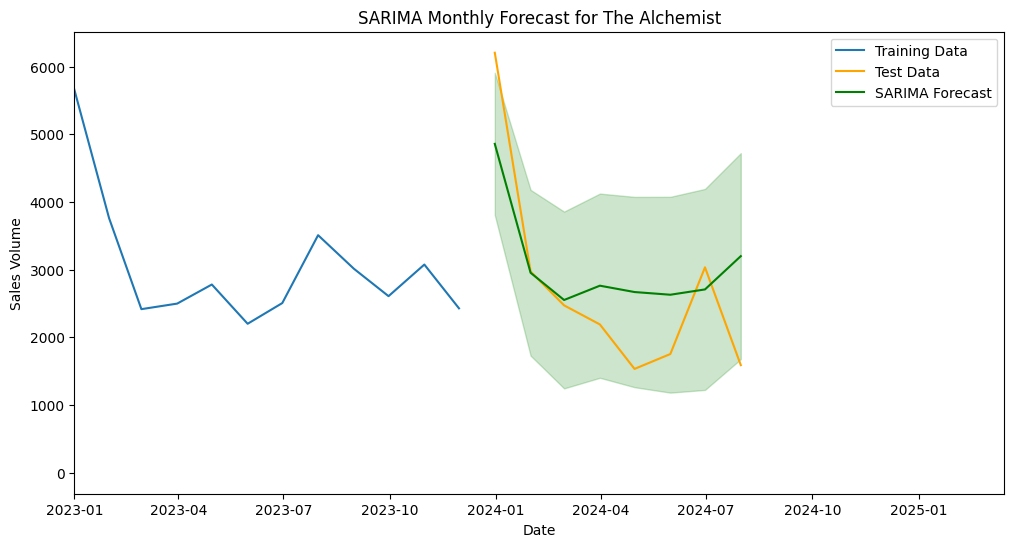

In [ ]:
#Zoom in for a better look.
plt.figure(figsize=(12, 6))
plt.plot(monthly_ts_train.index, monthly_ts_train, label='Training Data')
plt.plot(monthly_ts_test.index, monthly_ts_test, label='Test Data', color='orange')
plt.plot(forecast_monthly_sarima_index, forecast_monthly_sarima, label='SARIMA Forecast', color='green')
plt.fill_between(forecast_monthly_sarima_index, forecast_monthly_sarima_ci.iloc[:, 0], forecast_monthly_sarima_ci.iloc[:, 1], color='green', alpha=0.2)
plt.xlim(pd.Timestamp("2023-01-01", None))
plt.title('SARIMA Monthly Forecast for The Alchemist')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.show()

In [ ]:
#Evaluate
evaluate_forecast(monthly_ts_test, forecast_monthly_sarima)

MAE: 745.76
RMSE: 929.09
MAPE: 35.96%


(745.7561049745261, 929.0918693032685, 35.9613954658599)

Using the monthly SARIMA model, both forecasts appear visually accurate. However, the MAPE scores suggest differing performance. The Very Hungry Caterpillar achieves a best MAPE of 16.21%, whereas The Alchemist records a higher error of 35.96%.

# **XGBoost (Monthly)**

In [ ]:
monthly_lagged = create_lag_features(monthly_ts_train, 12)

In [ ]:
x_train_monthly = monthly_lagged.drop(columns=['y'])
y_train_monthly = monthly_lagged['y']

In [ ]:
####
#Best Hyperparameters for The Alchemist:
#window_length     12.000000
#max_depth          4.000000
#learning_rate      0.050000
#n_estimators     200.000000
#cv_mae            77.699354
#Name: 1, dtype: float64
####

monthly_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, window_length=12)
monthly_model.fit(x_train_monthly, y_train_monthly)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
def predict_next_xgb_monthly(history):
    x_input_monthly = np.array(history[-1:-best_window_xgb-1:-1]).reshape(1, -1)
    return monthly_model.predict(x_input_monthly)[0]

forecast_monthly = recursive_forecast(monthly_ts_train, 8, predict_next_xgb_monthly)

In [ ]:
forecast_monthly_series = pd.Series(forecast_monthly, index=monthly_ts_test.index)

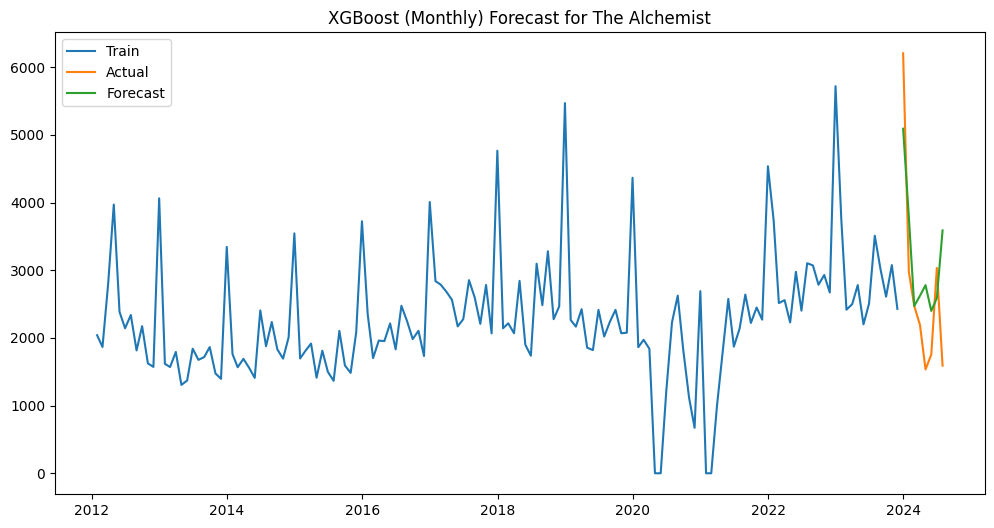

In [ ]:
plot_forecast(monthly_ts_train, monthly_ts_test, forecast_monthly_series, 'XGBoost (Monthly) Forecast for The Alchemist')

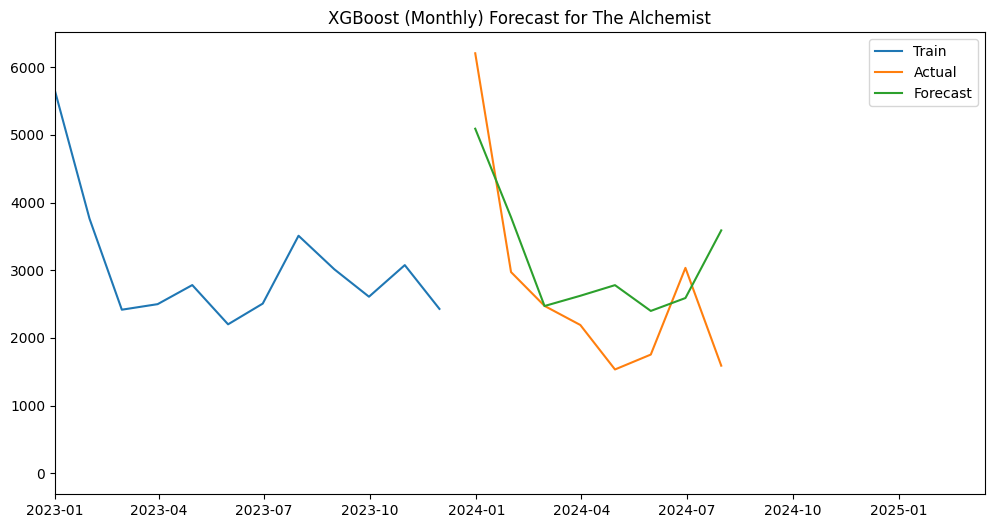

In [ ]:
plot_forecast_zoom(monthly_ts_train, monthly_ts_test, forecast_monthly_series, 'XGBoost (Monthly) Forecast for The Alchemist')

In [ ]:
#Evaluate
evaluate_forecast(monthly_ts_test, forecast_monthly_series)

MAE: 836.69
RMSE: 1015.41
MAPE: 40.42%


(836.69091796875, 1015.4144287109375, 40.42207598686218)

Similar to the monthly SARIMA results, the XGBoost model performs well for The Very Hungry Caterpillar but shows weaker performance for The Alchemist, indicating that the model generalises more effectively to one series than the other.

# **Comparison**

In [ ]:
# Weekly Models
mae_arima, rmse_arima, mape_arima = evaluate_forecast(ts_test, auto_arima_forecast)
mae_xgb, rmse_xgb, mape_xgb = evaluate_forecast(ts_test, forecast_best_xgb)
mae_lstm, rmse_lstm, mape_lstm = evaluate_forecast(ts_test, forecast_lstm_inverse)
mae_seq_hybrid, rmse_seq_hybrid, mape_seq_hybrid = evaluate_forecast(ts_test, combined_s_hybrid_forecast)
mae_par_hybrid, rmse_par_hybrid, mape_par_hybrid = evaluate_forecast(ts_test, best_parallel_hybrid)

# Monthly Models
mae_monthly_sarima, rmse_monthly_sarima, mape_monthly_sarima = evaluate_forecast(monthly_ts_test, forecast_monthly_sarima)
mae_monthly_xgb, rmse_monthly_xgb, mape_monthly_xgb = evaluate_forecast(monthly_ts_test, forecast_monthly_series)


# Create a dictionary to store the results
results = {
    'Model': [
        'Auto ARIMA (Weekly)',
        'XGBoost (Weekly)',
        'LSTM (Weekly)',
        'Sequential Hybrid (Weekly)',
        'Parallel Hybrid (Weekly - Best Weights)',
        'SARIMA (Monthly)',
        'XGBoost (Monthly)'
    ],
    'MAE': [
        mae_arima,
        mae_xgb,
        mae_lstm,
        mae_seq_hybrid,
        mae_par_hybrid,
        mae_monthly_sarima,
        mae_monthly_xgb
    ],
    'RMSE': [
        rmse_arima,
        rmse_xgb,
        rmse_lstm,
        rmse_seq_hybrid,
        rmse_par_hybrid,
        rmse_monthly_sarima,
        rmse_monthly_xgb
    ],
    'MAPE (%)': [
        mape_arima,
        mape_xgb,
        mape_lstm,
        mape_seq_hybrid,
        mape_par_hybrid,
        mape_monthly_sarima,
        mape_monthly_xgb
    ]
}

# Create a DataFrame from the results dictionary
comparison_df = pd.DataFrame(results)

# Display the DataFrame
display(comparison_df)


MAE: 136.61
RMSE: 184.07
MAPE: 25.79%
MAE: 176.39
RMSE: 224.22
MAPE: 34.93%
MAE: 195.83
RMSE: 348.45
MAPE: 27.15%
MAE: 136.67
RMSE: 184.14
MAPE: 25.80%
MAE: 130.60
RMSE: 186.43
MAPE: 23.31%
MAE: 745.76
RMSE: 929.09
MAPE: 35.96%
MAE: 836.69
RMSE: 1015.41
MAPE: 40.42%


,Model,MAE,RMSE,MAPE (%)
0,Auto ARIMA (Weekly),136.613531,184.066623,25.790482
1,XGBoost (Weekly),176.389498,224.224330,34.925888
2,LSTM (Weekly),195.825195,348.446045,27.146921
3,Sequential Hybrid (Weekly),136.667193,184.144477,25.795464
4,Parallel Hybrid (Weekly - Best Weights),130.604682,186.434554,23.311043
5,SARIMA (Monthly),745.756105,929.091869,35.961395
6,XGBoost (Monthly),836.690918,1015.414429,40.422076


Across the board, The Very Hungry Caterpillar achieved lower MAPE scores compared to The Alchemist. However, as observed in the earlier Ljung–Box test results, a lower MAPE does not necessarily imply a better statistical fit. Although The Very Hungry Caterpillar generally shows stronger predictive accuracy, the Ljung–Box results indicated the presence of autocorrelation in the residuals, whereas The Alchemist—despite higher error metrics—showed residuals more consistent with white noise, suggesting a better representation of the underlying structure.
Overall, a consistent pattern emerges across both datasets. The Auto ARIMA models perform strongly in both cases and are only marginally outperformed by the hybrid approaches, which build upon the Auto ARIMA forecasts. Both hybrid models improve results slightly, with the parallel hybrid model achieving the best overall performance across most metrics.
The monthly SARIMA and XGBoost models achieve some of the lowest MAPE scores overall, particularly for Book 1. This may be attributed to the smoothing effect of aggregating the data to a monthly level, which reduces short-term volatility and makes the series easier to forecast. However, this improvement is not consistent across both datasets, as Book 2 does not show the same level of performance gain under monthly aggregation.
